In [45]:
import gmsh
import numpy as np
import matplotlib.pyplot as plt

gmsh.initialize()
gmsh.model.add("circle_mesh")

mesh_size = 0.1

rectangle = gmsh.model.occ.addRectangle(-1, -1, 0, 2, 2, tag=1)
# gmsh.model.occ.addCurveLoop([], 1)
# gmsh.model.occ.addPlaneSurface([1], 1)

p1 = gmsh.model.occ.addPoint(-0.8, -0.8, 0, mesh_size)
p2 = gmsh.model.occ.addPoint(-0.4, -0.4, 0, mesh_size)
p3 = gmsh.model.occ.addPoint(0, 0, 0, mesh_size)
p4 = gmsh.model.occ.addPoint(0.4, 0.4, 0, mesh_size)
p5 = gmsh.model.occ.addPoint(0.8, 0.8, 0, mesh_size)

l1 = gmsh.model.occ.addLine(p1, p2)
l2 = gmsh.model.occ.addLine(p2, p3)
l3 = gmsh.model.occ.addLine(p3, p4)
l4 = gmsh.model.occ.addLine(p4, p5)

gmsh.model.occ.fragment([(2,1)], [(1,l1),(1,l2),(1,l3),(1,l4)])

gmsh.model.occ.synchronize()


gmsh.model.mesh.setTransfiniteCurve(l1, 1)
gmsh.model.mesh.setTransfiniteCurve(l2, 1)
gmsh.model.mesh.setTransfiniteCurve(l3, 1)
gmsh.model.mesh.setTransfiniteCurve(l4, 1)





gmsh.option.setNumber("Mesh.CharacteristicLengthMax", mesh_size)
gmsh.model.mesh.generate(2)

node_tags, node_coords, _ = gmsh.model.mesh.getNodes()
Nodes = np.array(node_coords).reshape(-1, 3)[:, :2]

elem_types, elem_tags, node_tags = gmsh.model.mesh.getElements(2, 1)
tri_node_tags = node_tags[0]

Elements = np.array(tri_node_tags, dtype=int).reshape(-1, 3) - 1
gmsh.fltk.run()
gmsh.finalize()

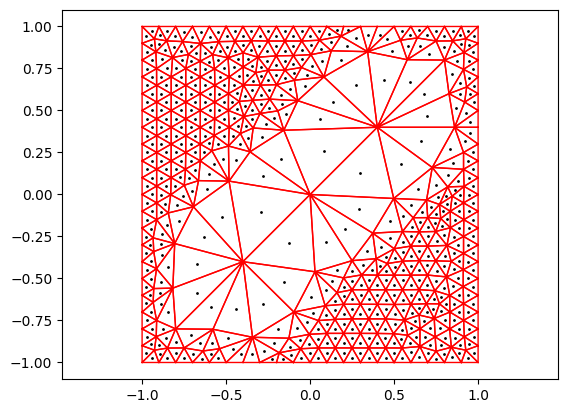

In [44]:
def plot_mesh(Nodes, Elements):
    for i, (a, b, c) in enumerate(Elements):
        x1, y1 = Nodes[a]
        x2, y2 = Nodes[b]
        x3, y3 = Nodes[c]
        x = (x1 + x2 + x3)/3
        y = (y1 + y2 + y3)/3
        plt.plot([x1, x2, x3, x1], [y1, y2, y3, y1], color='r', linewidth=1)
        plt.plot(x, y, 'ko', markersize=1)
    plt.axis('equal')
    plt.savefig('a.svg')
    plt.show()
plot_mesh(Nodes, Elements)